<a href="https://colab.research.google.com/github/ALYANANASUHAH/IDSC2026-AUTUMN-ANALYTICS---BRUGADA-/blob/main/AUTUMN_ANALYTICS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install wfdb matplotlib numpy

🚀 Starting ECG Signal Extraction Pipeline...
🔎 Found 363 patient records.

✅ PIPELINE COMPLETED SUCCESSFULLY!
• Total Patients Processed: 363
• Dataset Saved to: ./brugada_dataset_final.pkl

Class Distribution (0=Normal, 1=Brugada):
brugada
0    287
1     69
2      7
Name: count, dtype: int64
🔍 Enter Patient ID (e.g., 188981): 188981


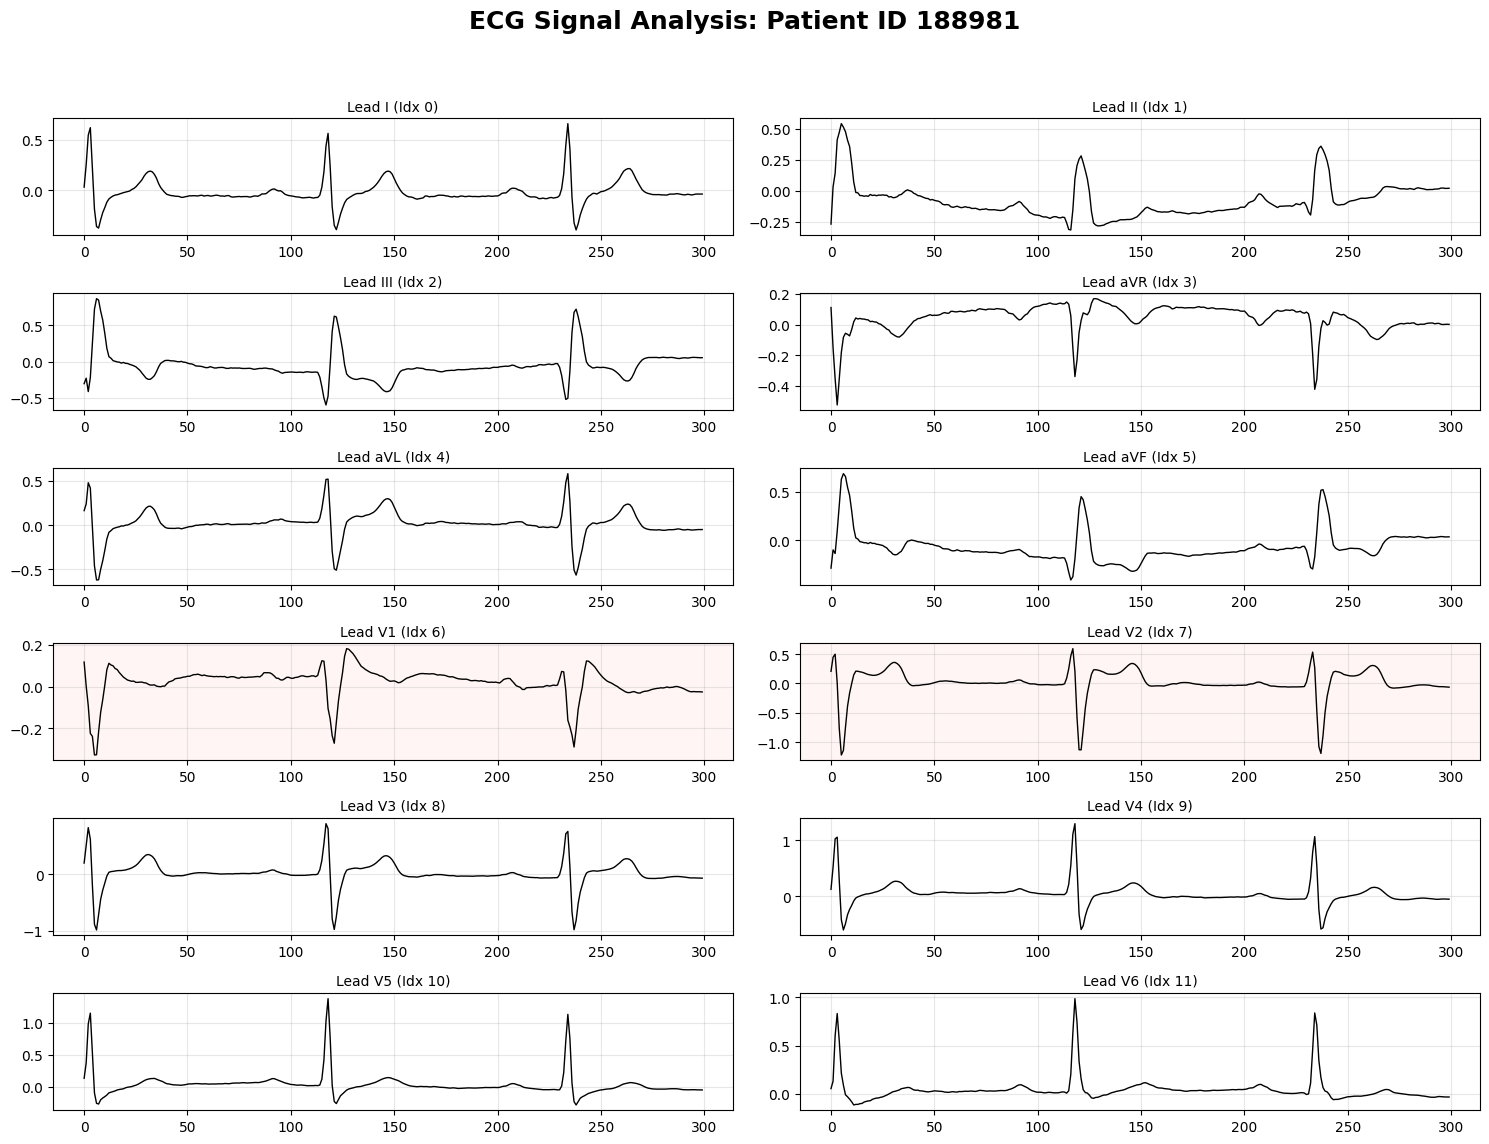

🔴 Dataset Diagnosis: BRUGADA TYPE 1 (Coved Type)
✅ Successfully displayed signals for Patient 188981


In [6]:
# =================================================================
# 1. INSTALL & IMPORT LIBRARIES
# =================================================================
try:
    import wfdb
except:
    !pip install wfdb openpyxl
    import wfdb

import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# 2. PATH CONFIGURATION
# =================================================================
def setup_paths():
    """Configures file paths for local Sidebar environment."""
    # We strictly use Sidebar for better jury accessibility
    base = './'

    return {
        'data': os.path.join(base, 'PATIENT/'),
        'meta': os.path.join(base, 'metadata.csv'),
        'output': os.path.join(base, 'brugada_dataset_final.pkl')}

# =================================================================
# 3. FUNCTION: VISUALIZATION (12-LEADS)
# =================================================================
def plot_professional_ecg(record, pid):
    """Plots 12-lead ECG signals with focus on V1 & V2 leads."""
    fig, axs = plt.subplots(6, 2, figsize=(15, 12))
    fig.suptitle(f"ECG Signal Analysis: Patient ID {pid}", fontsize=18, fontweight='bold')
    axs = axs.flatten()

    for i in range(12):
        # Taking 300 samples (approx. 3 seconds) for clarity
        axs[i].plot(record.p_signal[:300, i], color='black', linewidth=1)
        axs[i].set_title(f"Lead {record.sig_name[i]} (Idx {i})", fontsize=10)
        axs[i].grid(True, alpha=0.3)

        # Highlighting Lead V1 (Idx 6) and V2 (Idx 7) - Primary Brugada diagnostic leads
        if i == 6 or i == 7:
            axs[i].set_facecolor('#FFF5F5') # Soft pink highlight

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# =================================================================
# 4. FUNCTION: DATA EXTRACTION
# =================================================================
def process_ecg_data(paths):
    """Reads .hea/.dat files and extracts V1/V2 signals as State inputs."""
    if not os.path.exists(paths['data']):
        print(f"❌ ERROR: Folder '{paths['data']}' not found in sidebar!")
        return pd.DataFrame()

    # Listing .hea files
    patient_ids = [f.replace('.hea', '') for f in os.listdir(paths['data']) if f.endswith('.hea')]
    print(f"🔎 Found {len(patient_ids)} patient records.")

    extracted_data = []

    for pid in patient_ids:
        try:
            # Load record (WFDB automatically locates .dat files)
            record = wfdb.rdrecord(os.path.join(paths['data'], pid))

            # Extract V1 & V2 signals (Critical features for RL Environment)
            # We use 300 samples as the representative state for each patient
            v1_sig = record.p_signal[:300, 6]
            v2_sig = record.p_signal[:300, 7]

            extracted_data.append({
                'patient_id': str(pid),
                'V1_Signal': v1_sig,
                'V2_Signal': v2_sig
            })
        except Exception as e:
            print(f"⚠️ Skipping ID {pid} due to error: {e}")

    return pd.DataFrame(extracted_data)

# =================================================================
# 5. MAIN EXECUTION
# =================================================================
if __name__ == "__main__":
    # Step A: Setup Paths (Points to Sidebar 'PATIENT' folder)
    paths = setup_paths()

    # Step B: Start Signal Extraction
    # This will now only print progress without showing any plots
    print("🚀 Starting ECG Signal Extraction Pipeline...")
    df_signals = process_ecg_data(paths)

    # Step C: Merge with metadata.csv & Save for RL Training
    if not df_signals.empty:
        if os.path.exists(paths['meta']):
            try:
                # Load clinical metadata
                metadata = pd.read_csv(paths['meta'])

                # Standardizing ID formats for seamless merging
                metadata['patient_id'] = metadata['patient_id'].astype(str)
                df_signals['patient_id'] = df_signals['patient_id'].astype(str)

                # Merging ECG signals with Brugada diagnosis labels
                final_df = pd.merge(df_signals, metadata[['patient_id', 'brugada']], on='patient_id')

                # Save the processed dataset as a Pickle file (Standard for ML/RL)
                final_df.to_pickle(paths['output'])

                print("\n" + "="*45)
                print("✅ PIPELINE COMPLETED SUCCESSFULLY!")
                print(f"• Total Patients Processed: {len(final_df)}")
                print(f"• Dataset Saved to: {paths['output']}")
                print("="*45)

                # Display class balance to the jury
                print("\nClass Distribution (0=Normal, 1=Brugada):")
                print(final_df['brugada'].value_counts())

            except Exception as merge_err:
                print(f"❌ Error during metadata merge: {merge_err}")
        else:
            print(f"❌ ERROR: 'metadata.csv' not found! Please upload to sidebar.")
    else:
        print("❌ Pipeline failed: No ECG signals were extracted.")

# =================================================================
# 6. INTERACTIVE SEARCH DASHBOARD
# =================================================================
search_id = input("🔍 Enter Patient ID (e.g., 188981): ")

try:
    # 1. Visualization
    paths = setup_paths()
    record_path = os.path.join(paths['data'], str(search_id))
    record = wfdb.rdrecord(record_path)
    plot_professional_ecg(record, search_id)

    # 2. Diagnosis Retrieval
    if 'final_df' in locals() or 'metadata' in locals():
        diagnosis_row = metadata[metadata['patient_id'] == str(search_id)]

        if not diagnosis_row.empty:
            label = diagnosis_row['brugada'].values[0]

            if label == 1:
                result = "BRUGADA TYPE 1 (Coved Type)"
                icon = "🔴"
            elif label == 2:
                result = "BRUGADA TYPE 2 (Saddle-back Type)"
                icon = "🟠"
            else:
                result = "NORMAL"
                icon = "🟢"

            print(f"{icon} Dataset Diagnosis: {result}")
            print(f"✅ Successfully displayed signals for Patient {search_id}")
        else:
            print(f"⚠️ Signals found, but ID {search_id} is missing from metadata.csv")

except Exception as e:
    print(f"❌ ID {search_id} not found or system error occurred.")
    print(f"Detail: {e}")